# Synthetic SBM: Self vs Neighbor Effects (Spillovers)

This notebook mirrors `experiment_separate_self_neighbor.ipynb`, but instead of using `Flickr_New.npz` / `BC_New.npz`, it works on a **simulated stochastic block model (SBM) graph** with Gaussian covariates.

Pipeline (train & test):
- Generate SBM graphs (train and test) with shared hyperparameters but different random seeds.
- Simulate treatments and outcomes using the same `simulate_treatment` and `compute_outcome` functions.
- Fit nuisance components (propensity score and mean outcome) or use oracle nuisances.
- Fit the attention GCN in the appropriate outcome mode (with-self or separate-self).
- Run multiplier bootstrap for the attention model and compute pointwise + uniform coverage bands for:
  - Attention weights `W_true`.
  - Raw MLP scores `raw_scores` (pre-softmax).
- Visualize individual effects and coverage behavior.


In [14]:
import numpy as np
import torch

from addition import generate_sbm_graph, generate_covariates
from simulation import simulate_treatment, compute_outcome
from train import (
    GraphData,
    TrainConfig,
    PropensityConfig,
    MeanConfig,
    AttentionConfig,
    fit_propensity,
    fit_mean,
    fit_attention,
    bootstrap_attention,
)
from metric import (
    compute_individual_effects,
    evaluate,
)

torch.set_num_threads(4)


### Config


In [15]:
# SBM graph hyperparameters
n = 5000
num_communities = 10
p = 0.005
q = 0.0005
train_fraction = 0.7

# Outcome mode: "with_self" (single-head) or "separate_self" (two-head)
outcome_mode = "separate_self"  # change to "with_self" if desired
include_self_loop = (outcome_mode == "with_self")
low_dimension = False  # explicitly use full X for f and g

# Attention similarities
f_type = "cosine"  # neighbor attention f(X_i, X_j)
g_type = "heter"   # self treatment g(X_i) (used only in separate_self mode)
attn_temperature = 0.0

# Semi-synthetic outcome hyperparameters
beta = 1.0
alpha_treat = 2.0
sigma = 0.05
scale = 5.0
num_partition = 3
ratio_self = 1.0

# Nuisance config: True = fit nuisances; False = use oracle (m_star, e_star)
fit_nuisance = False

# Bootstrap config
B = 120
alpha_ci = 0.05
multiplier_dist = "normal"  # or "rademacher"

# Attention training config
train_cfg_attn = TrainConfig(epochs=400, lr=3e-4, batch_size=64, patience=12, device="cpu", log_every=1)
attn_cfg = AttentionConfig(hidden_dim=64, attn_temperature=attn_temperature, separate_self=(outcome_mode=="separate_self"))



### Generate SBM graphs and covariates


In [16]:
# Set base seed for reproducibility
seed = 41
np.random.seed(seed)
torch.manual_seed(seed)

# Train graph
A_train, community_labels_train = generate_sbm_graph(
    n=n,
    num_communities=num_communities,
    p=p,
    q=q,
    seed=seed,
)
X_train = generate_covariates(n=n, d=5, seed=seed)

# Add self-loops to match real-data pipeline before simulate_treatment
A_train = A_train + np.eye(A_train.shape[0])

# Test graph (same hyperparameters, different seed)
A_test, community_labels_test = generate_sbm_graph(
    n=n,
    num_communities=num_communities,
    p=p,
    q=q,
    seed=seed + 1,
)
X_test = generate_covariates(n=n, d=5, seed=seed + 1)

A_test = A_test + np.eye(A_test.shape[0])

print("Train avg degree:", np.mean(A_train.sum(axis=1)))
print("Test avg degree:", np.mean(A_test.sum(axis=1)))


Train avg degree: 5.7788
Test avg degree: 5.7996


### Semi-synthetic treatment and outcome generation


In [17]:
# Train split: simulate treatment and outcome
nbrs_idx, n_train, d_train, partitions, t, e_star, treat_neighbor, treat_matrix = simulate_treatment(
    X_train,
    A_train,
    mode="train",
    beta=beta,
    alpha=alpha_treat,
    num_partitions=num_partition,
    include_self_loop=include_self_loop,
)

W_true, spillover_true, U_0, noise, y, m_star, self_effect_true, raw_scores = compute_outcome(
    X_train,
    A_train,
    treat_matrix,
    e_star,
    n_train,
    sigma,
    scale,
    attn_temperature,
    name=f_type,
    outcome_mode=outcome_mode,
    self_name=g_type,
    t=t,
    w_self=ratio_self,
    low_dimension=low_dimension,
)

IME, ISE, ITE = compute_individual_effects(W_true, A_train, outcome_mode=outcome_mode, g_self=self_effect_true)

# Test split: simulate treatment and outcome
nbrs_idx_test, n_test, d_test, partitions_test, t_test, e_star_test, treat_neighbor_test, treat_matrix_test = simulate_treatment(
    X_test,
    A_test,
    mode="test",
    beta=beta,
    alpha=alpha_treat,
    include_self_loop=include_self_loop,
)

(
    W_true_test,
    spillover_true_test,
    U_0_test,
    noise_test,
    y_test,
    m_star_test,
    self_effect_true_test,
    raw_scores_test,
) = compute_outcome(
    X_test,
    A_test,
    treat_matrix_test,
    e_star_test,
    n_test,
    sigma,
    scale,
    attn_temperature,
    name=f_type,
    outcome_mode=outcome_mode,
    self_name=g_type,
    t=t_test,
    w_self=ratio_self,
    low_dimension=low_dimension,
)

IME_test, ISE_test, ITE_test = compute_individual_effects(W_true_test, A_test, outcome_mode=outcome_mode, g_self=self_effect_true_test)



### Fit nuisance components (propensity and mean)


In [18]:
# Train configs for nuisances
train_cfg_pm = TrainConfig(epochs=500, lr=5e-2, batch_size=n_train, patience=12, device="cpu", log_every=40)
prop_cfg = PropensityConfig(hidden_dim=128)
mean_cfg = MeanConfig(hidden_dim=128)

data = GraphData(X=X_train, y=y, A=A_train, nbrs_idx=nbrs_idx, t=t, fold_assignments=partitions)

if fit_nuisance:
    fr_p, data = fit_propensity(data, train_cfg_pm, prop_cfg)
    fr_m, data = fit_mean(data, train_cfg_pm, mean_cfg)
else:
    data.mu_hat = m_star
    data.e_hat = e_star

mu_hat = data.mu_hat
e_hat = data.e_hat

print("sum (mu_hat - m_star)^2 =", np.sum((mu_hat - m_star) ** 2))
print("sum (e_hat - e_star)^2 =", np.sum((e_hat - e_star) ** 2))


sum (mu_hat - m_star)^2 = 0.0
sum (e_hat - e_star)^2 = 0.0


### Fit attention model and evaluate causal effects


In [19]:
nbrs_idx

[tensor([   0,  483, 4387]),
 tensor([   1,   85,  128, 4979]),
 tensor([   2,   22,   52, 4477]),
 tensor([   3,  175,  176,  261,  451,  896, 1635]),
 tensor([   4,   89,  142,  247, 2510]),
 tensor([   5,  180,  428,  467,  488,  982, 2053]),
 tensor([   6,   48,  211,  416,  831,  990, 1525, 2224, 3147, 3541, 3950]),
 tensor([   7,  362,  839,  876, 3860]),
 tensor([   8,  429,  457,  622, 2233, 3203, 4709]),
 tensor([   9,  141,  403, 3627, 3944, 4000]),
 tensor([  10,  173,  393, 2456, 2745, 3454, 4375]),
 tensor([  11,  893, 1709, 3562]),
 tensor([  12,  114,  326,  335,  513, 2188, 2909, 3586]),
 tensor([ 13, 443]),
 tensor([  14,  167,  434,  527,  846, 3933]),
 tensor([  15,  355, 1894]),
 tensor([  16,  224,  248, 2608]),
 tensor([  17,   66,  314, 4492]),
 tensor([  18,  124,  165,  289,  326,  362,  436, 1013, 4769]),
 tensor([  19,  229,  335,  358, 2611, 3421, 4454]),
 tensor([  20,  340,  497, 3069, 3578, 4888]),
 tensor([  21,  116,  145,  764, 2073, 4533, 4582]),
 ten

In [20]:
# Fit attention
fr_a = fit_attention(
    data=data,
    train_cfg=train_cfg_attn,
    attn_cfg=attn_cfg,
    attn_true=W_true,
    attn_true_self=self_effect_true,
)

print("Done fitting attention.")

# Evaluate individual effects (train)
with torch.no_grad():
    out = fr_a.model.cpu().predict(
        torch.tensor(X_train, dtype=torch.float32),
        nbrs_idx,
        torch.tensor(t, dtype=torch.float32),
    )
W_pred, g_pred = (out[0], out[2]) if isinstance(out, tuple) and len(out) == 3 else (out[0], None)
IME_est, ISE_est, ITE_est = compute_individual_effects(W_pred, A_train, outcome_mode, g_self=g_pred)
print("Proposed: training set")
Result_train = evaluate(IME, ISE, ITE, IME_est, ISE_est, ITE_est, printing=True)

# Evaluate individual effects (test)
with torch.no_grad():
    out_test = fr_a.model.predict(
        torch.tensor(X_test, dtype=torch.float32),
        nbrs_idx_test,
        torch.tensor(t_test, dtype=torch.float32),
    )
W_pred_test, g_pred_test = (out_test[0], out_test[2]) if isinstance(out_test, tuple) and len(out_test) == 3 else (out_test[0], None)
IME_est_test, ISE_est_test, ITE_est_test = compute_individual_effects(W_pred_test, A_test, outcome_mode, g_self=g_pred_test)
print("Proposed: testing set")
Result_test = evaluate(IME_test, ISE_test, ITE_test, IME_est_test, ISE_est_test, ITE_est_test, printing=True)


Epoch 001, New best Spillover diff: 4667.1005
Epoch 002, New best Spillover diff: 1149.5376
Epoch 003, New best Spillover diff: 435.6675
Epoch 004, New best Spillover diff: 318.4251
Epoch 005, New best Spillover diff: 252.8112
Epoch 006, New best Spillover diff: 210.0079
Epoch 007, New best Spillover diff: 171.8032
Epoch 008, New best Spillover diff: 140.3720
Epoch 009, New best Spillover diff: 113.4793
Epoch 010, New best Spillover diff: 90.9489
Epoch 011, New best Spillover diff: 76.1490
Epoch 012, New best Spillover diff: 69.2942
Epoch 013, New best Spillover diff: 60.9883
Epoch 014, New best Spillover diff: 56.3592
Epoch 015, New best Spillover diff: 50.7972
Epoch 016, New best Spillover diff: 49.5721
Epoch 017, New best Spillover diff: 47.6895
No improve. Epoch 018, Spillover diff: 48.1575
Epoch 019, New best Spillover diff: 45.6206
Epoch 020, New best Spillover diff: 44.5097
Epoch 021, New best Spillover diff: 42.7808
No improve. Epoch 022, Spillover diff: 43.9605
Epoch 023, New 

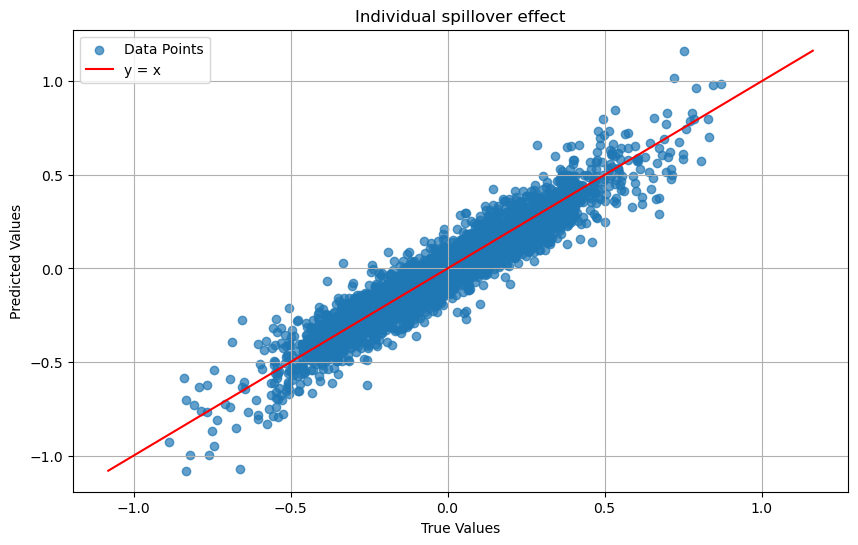

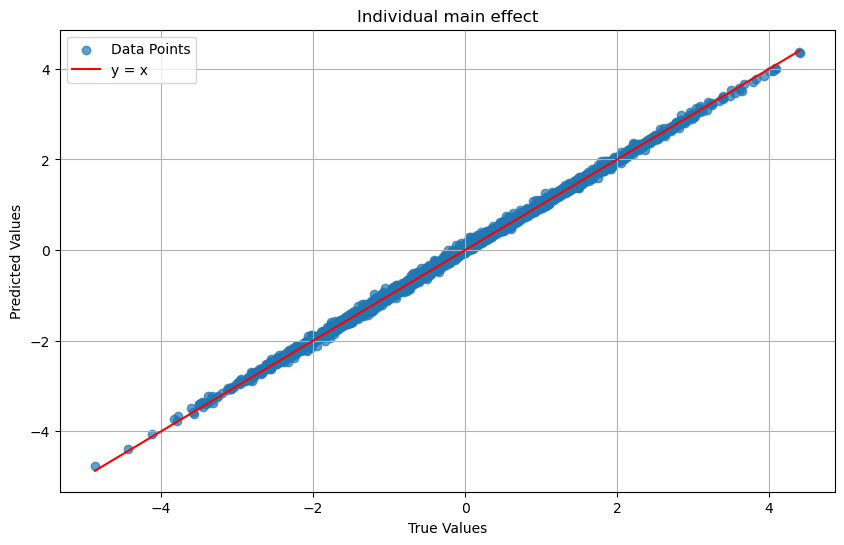

In [21]:
from utils import plot_true_vs_pred
plot_true_vs_pred(ISE,ISE_est,title_name="Individual spillover effect")
plot_true_vs_pred(IME_test,IME_est_test,title_name="Individual main effect")


### Bootstrap attention and coverage (train & test)


In [22]:
# Bootstrap attention with train GraphData and test graph for coverage
boot_res = bootstrap_attention(
    data=data,
    train_cfg=train_cfg_attn,
    attn_cfg=attn_cfg,
    attn_true=W_true,
    attn_true_self=self_effect_true,
    B=B,
    alpha=alpha_ci,
    multiplier_dist=multiplier_dist,
    X_test=X_test,
    nbrs_idx_test=nbrs_idx_test,
    t_test=t_test,
)

base_attn = boot_res.base_attn                 # [n_train, n_train]
ci_lo_pw = boot_res.ci_pointwise_lower        # [n_train, n_train]
ci_hi_pw = boot_res.ci_pointwise_upper
ci_lo_unif = boot_res.ci_uniform_lower        # [n_train, n_train]
ci_hi_unif = boot_res.ci_uniform_upper

base_raw = boot_res.base_raw
ci_lo_pw_raw = boot_res.ci_pointwise_lower_raw
ci_hi_pw_raw = boot_res.ci_pointwise_upper_raw
ci_lo_unif_raw = boot_res.ci_uniform_lower_raw
ci_hi_unif_raw = boot_res.ci_uniform_upper_raw



[bootstrap] Fitting baseline attention model (unweighted)...
Epoch 001, New best Spillover diff: 4642.5368
Epoch 002, New best Spillover diff: 932.5958
Epoch 003, New best Spillover diff: 366.2311
Epoch 004, New best Spillover diff: 292.9976
Epoch 005, New best Spillover diff: 244.7835
Epoch 006, New best Spillover diff: 208.1575
Epoch 007, New best Spillover diff: 174.6674
Epoch 008, New best Spillover diff: 143.0902
Epoch 009, New best Spillover diff: 120.4259
Epoch 010, New best Spillover diff: 100.9086
Epoch 011, New best Spillover diff: 85.1739
Epoch 012, New best Spillover diff: 77.2839
Epoch 013, New best Spillover diff: 67.3065
Epoch 014, New best Spillover diff: 60.7564
Epoch 015, New best Spillover diff: 55.1455
Epoch 016, New best Spillover diff: 52.5443
No improve. Epoch 017, Spillover diff: 53.8140
Epoch 018, New best Spillover diff: 47.5403
Epoch 019, New best Spillover diff: 45.0107
Epoch 020, New best Spillover diff: 43.5527
No improve. Epoch 021, Spillover diff: 44.480

KeyboardInterrupt: 

In [ ]:
# Train coverage for W_true
import numpy as np

nonzero_mask = (W_true != 0)

covered_pw = ((W_true >= ci_lo_pw) & (W_true <= ci_hi_pw)) & nonzero_mask
n_nonzero = nonzero_mask.sum()
coverage_pw = covered_pw.sum() / n_nonzero if n_nonzero > 0 else np.nan
print(f"[Train] Pointwise CI (W_true != 0): {coverage_pw:.3f} ({covered_pw.sum()} / {n_nonzero})")

covered_unif = ((W_true >= ci_lo_unif) & (W_true <= ci_hi_unif)) & nonzero_mask
coverage_unif = covered_unif.sum() / n_nonzero if n_nonzero > 0 else np.nan
print(f"[Train] Uniform CI  (W_true != 0): {coverage_unif:.3f} ({covered_unif.sum()} / {n_nonzero})")

# Train coverage for raw_scores
nonzero_mask_raw = (raw_scores != 0)
covered_pw_raw = ((raw_scores >= ci_lo_pw_raw) & (raw_scores <= ci_hi_pw_raw)) & nonzero_mask_raw
n_nonzero_raw = nonzero_mask_raw.sum()
coverage_pw_raw = covered_pw_raw.sum() / n_nonzero_raw if n_nonzero_raw > 0 else np.nan
print(f"[Train] Pointwise CI (raw != 0): {coverage_pw_raw:.3f} ({covered_pw_raw.sum()} / {n_nonzero_raw})")

covered_unif_raw = ((raw_scores >= ci_lo_unif_raw) & (raw_scores <= ci_hi_unif_raw)) & nonzero_mask_raw
coverage_unif_raw = covered_unif_raw.sum() / n_nonzero_raw if n_nonzero_raw > 0 else np.nan
print(f"[Train] Uniform CI  (raw != 0): {coverage_unif_raw:.3f} ({covered_unif_raw.sum()} / {n_nonzero_raw})")



In [ ]:
# Test coverage, using coverage info from metrics-style structure if desired
# Here we recompute directly from boot_res.*_test and W_true_test / raw_scores_test

if (
    boot_res.base_attn_test is not None
    and boot_res.boot_attn_test is not None
    and boot_res.base_raw_test is not None
    and boot_res.boot_raw_test is not None
):
    base_attn_test = boot_res.base_attn_test
    boot_attn_test = boot_res.boot_attn_test
    base_raw_test = boot_res.base_raw_test
    boot_raw_test = boot_res.boot_raw_test

    # Pointwise and uniform CIs for attention on test graph
    diffs_test = boot_attn_test - base_attn_test[None, :, :]
    radius_pointwise_test = np.quantile(np.abs(diffs_test), 1.0 - alpha_ci / 2.0, axis=0)
    ci_lo_pw_test = base_attn_test - radius_pointwise_test
    ci_hi_pw_test = base_attn_test + radius_pointwise_test

    max_dev_test = np.max(np.abs(diffs_test).reshape(boot_attn_test.shape[0], -1), axis=1)
    c_uniform_test = np.quantile(max_dev_test, 1.0 - alpha_ci)
    ci_lo_unif_test = base_attn_test - c_uniform_test
    ci_hi_unif_test = base_attn_test + c_uniform_test

    # Coverage on nonzero W_true_test
    nonzero_mask_test = (W_true_test != 0)
    n_nonzero_test = nonzero_mask_test.sum()
    covered_pw_test = ((W_true_test >= ci_lo_pw_test) & (W_true_test <= ci_hi_pw_test)) & nonzero_mask_test
    covered_unif_test = ((W_true_test >= ci_lo_unif_test) & (W_true_test <= ci_hi_unif_test)) & nonzero_mask_test

    cov_pw_test = covered_pw_test.sum() / n_nonzero_test if n_nonzero_test > 0 else np.nan
    cov_unif_test = covered_unif_test.sum() / n_nonzero_test if n_nonzero_test > 0 else np.nan

    print(f"[Test] Pointwise CI (W_true != 0): {cov_pw_test:.3f} ({covered_pw_test.sum()} / {n_nonzero_test})")
    print(f"[Test] Uniform CI  (W_true != 0): {cov_unif_test:.3f} ({covered_unif_test.sum()} / {n_nonzero_test})")

    # Raw scores on test
    diffs_raw_test = boot_raw_test - base_raw_test[None, :, :]
    radius_pointwise_raw_test = np.quantile(np.abs(diffs_raw_test), 1.0 - alpha_ci / 2.0, axis=0)
    ci_lo_pw_raw_test = base_raw_test - radius_pointwise_raw_test
    ci_hi_pw_raw_test = base_raw_test + radius_pointwise_raw_test

    max_dev_raw_test = np.max(np.abs(diffs_raw_test).reshape(boot_raw_test.shape[0], -1), axis=1)
    c_uniform_raw_test = np.quantile(max_dev_raw_test, 1.0 - alpha_ci)
    ci_lo_unif_raw_test = base_raw_test - c_uniform_raw_test
    ci_hi_unif_raw_test = base_raw_test + c_uniform_raw_test

    nonzero_mask_raw_test = (raw_scores_test != 0)
    n_nonzero_raw_test = nonzero_mask_raw_test.sum()
    covered_pw_raw_test = (
        (raw_scores_test >= ci_lo_pw_raw_test) & (raw_scores_test <= ci_hi_pw_raw_test)
    ) & nonzero_mask_raw_test
    covered_unif_raw_test = (
        (raw_scores_test >= ci_lo_unif_raw_test) & (raw_scores_test <= ci_hi_unif_raw_test)
    ) & nonzero_mask_raw_test

    cov_pw_raw_test = covered_pw_raw_test.sum() / n_nonzero_raw_test if n_nonzero_raw_test > 0 else np.nan
    cov_unif_raw_test = covered_unif_raw_test.sum() / n_nonzero_raw_test if n_nonzero_raw_test > 0 else np.nan

    print(f"[Test] Pointwise CI (raw != 0): {cov_pw_raw_test:.3f} ({covered_pw_raw_test.sum()} / {n_nonzero_raw_test})")
    print(f"[Test] Uniform CI  (raw != 0): {cov_unif_raw_test:.3f} ({covered_unif_raw_test.sum()} / {n_nonzero_raw_test})")
else:
    print("boot_res does not contain test-side predictions; rerun with updated train.bootstrap_attention.")

